In [16]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import pointbiserialr
import matplotlib.pyplot as plt
from src.utils.config import load_config
from src.data.colley import compute_colley_ratings
from src.data.dataset import parse_seed

In [17]:
config = load_config()
team_stats = pd.read_csv(f'{config["data"]["processed_dir"]}/team_stats_baseline.csv')
tourney_results = pd.read_csv('data/raw/MNCAATourneyCompactResults.csv')
season_results = pd.read_csv('data/raw/MRegularSeasonDetailedResults.csv')
seeds = pd.read_csv('data/raw/MNCAATourneySeeds.csv')

train_start, train_end = config['data']['train_seasons']

colley_ratings = compute_colley_ratings(season_results)
team_stats = pd.merge(team_stats, colley_ratings, on=['season', 'team_id'], how='left')

seeds['seed'] = seeds['Seed'].apply(parse_seed)
seeds = seeds[['Season', 'TeamID', 'seed']]

train_stats = team_stats[(team_stats['season'] >= train_start) & (team_stats['season'] <= train_end)]
train_tourney = tourney_results[(tourney_results['Season'] >= train_start) & (tourney_results['Season'] <= train_end)]

winner_matchups = pd.merge(
    left=train_tourney, right=train_stats,
    left_on=['Season', 'WTeamID'], right_on=['season', 'team_id']
)
all_matchups = pd.merge(
    left=winner_matchups, right=train_stats,
    left_on=['Season', 'LTeamID'], right_on=['season', 'team_id'],
    suffixes=(None, '_l')
)
all_matchups = pd.merge(
    left=all_matchups, right=seeds,
    left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID']
)
all_matchups = pd.merge(
    left=all_matchups, right=seeds,
    left_on=['Season', 'LTeamID'], right_on=['Season', 'TeamID'],
    suffixes=(None, '_l')
)

all_matchups['colley_diff'] = all_matchups['colley'] - all_matchups['colley_l']
all_matchups['win_pct_diff'] = all_matchups['win_pct'] - all_matchups['win_pct_l']
all_matchups['seed_diff'] = all_matchups['seed'] - all_matchups['seed_l']

matchups = all_matchups[['colley_diff', 'win_pct_diff', 'seed_diff']].copy()
matchups['label'] = 1

mirrored = matchups.copy()
mirrored[['colley_diff', 'win_pct_diff', 'seed_diff']] = -mirrored[['colley_diff', 'win_pct_diff', 'seed_diff']]
mirrored['label'] = 0
matchups = pd.concat([matchups, mirrored], ignore_index=True)

screen_train, screen_val = train_test_split(
    matchups, test_size=0.2, random_state=config['training']['random_seed'], stratify=matchups['label']
)

colley_corr, _ = pointbiserialr(matchups['label'], matchups['colley_diff'])

lr = LogisticRegression()
lr.fit(screen_train[['colley_diff']], screen_train['label'])
colley_probs = lr.predict_proba(screen_val[['colley_diff']])[:, 1]
colley_auc = roc_auc_score(screen_val['label'], colley_probs)

redundancy_win_pct = matchups['colley_diff'].corr(matchups['win_pct_diff'])
redundancy_seed = matchups['colley_diff'].corr(matchups['seed_diff'])

print(f'colley_diff correlation with label: {colley_corr:.4f}')
print(f'colley_diff single-feature AUC: {colley_auc:.4f}')
print(f'colley_diff redundancy with win_pct_diff: {redundancy_win_pct:.4f}')
print(f'colley_diff redundancy with seed_diff: {redundancy_seed:.4f}')

colley_diff correlation with label: 0.4680
colley_diff single-feature AUC: 0.7568
colley_diff redundancy with win_pct_diff: 0.7579
colley_diff redundancy with seed_diff: -0.9355


In [19]:
seed_only = LogisticRegression()
seed_only.fit(screen_train[['seed_diff']], screen_train['label'])
seed_only_auc = roc_auc_score(screen_val['label'], seed_only.predict_proba(screen_val[['seed_diff']])[:, 1])

seed_colley = LogisticRegression()
seed_colley.fit(screen_train[['seed_diff', 'colley_diff']], screen_train['label'])
seed_colley_auc = roc_auc_score(screen_val['label'], seed_colley.predict_proba(screen_val[['seed_diff', 'colley_diff']])[:, 1])

print(f'seed_diff alone: {seed_only_auc:.4f}')
print(f'seed_diff + colley_diff: {seed_colley_auc:.4f}')

seed_diff alone: 0.7655
seed_diff + colley_diff: 0.7653


In [8]:
config = load_config()
team_stats = pd.read_csv(f'{config["data"]["processed_dir"]}/team_stats_baseline.csv')
tourney_results = pd.read_csv('data/raw/MNCAATourneyCompactResults.csv')

train_start, train_end = config['data']['train_seasons']
window = 5

stat_cols = ['points_scored', 'points_allowed', 'shots_made', 'shots_attempted', 'threes_made',
             'threes_attempted', 'free_throws_made', 'free_throws_attempted', 'offensive_rebounds',
             'defensive_rebounds', 'assists', 'turnovers', 'steals', 'blocks', 'fouls',
             'win_pct', 'fg_pct', 'three_pct', 'free_throw_pct']

team_stats = team_stats.sort_values(['team_id', 'season'])

# shift(1) excludes the current season from its own trailing average, so momentum
# never leaks this season's outcome into its own trend feature
for stat in stat_cols:
    trailing_avg = team_stats.groupby('team_id')[stat].transform(
        lambda s: s.shift(1).rolling(window=window, min_periods=1).mean()
    )
    team_stats[f'{stat}_momentum'] = (team_stats[stat] - trailing_avg).fillna(0)

train_stats = team_stats[(team_stats['season'] >= train_start) & (team_stats['season'] <= train_end)]
train_tourney = tourney_results[(tourney_results['Season'] >= train_start) & (tourney_results['Season'] <= train_end)]

winner_matchups = pd.merge(
    left=train_tourney, right=train_stats,
    left_on=['Season', 'WTeamID'], right_on=['season', 'team_id']
)
all_matchups = pd.merge(
    left=winner_matchups, right=train_stats,
    left_on=['Season', 'LTeamID'], right_on=['season', 'team_id'],
    suffixes=(None, '_l')
)

momentum_cols = [f'{stat}_momentum' for stat in stat_cols]
for stat in stat_cols + momentum_cols:
    all_matchups[f'{stat}_diff'] = all_matchups[stat] - all_matchups[f'{stat}_l']

diff_cols = [f'{stat}_diff' for stat in stat_cols]
momentum_diff_cols = [f'{stat}_diff' for stat in momentum_cols]

matchups = all_matchups[diff_cols + momentum_diff_cols].copy()
matchups['label'] = 1

mirrored = matchups.copy()
mirrored[diff_cols + momentum_diff_cols] = -mirrored[diff_cols + momentum_diff_cols]
mirrored['label'] = 0
matchups = pd.concat([matchups, mirrored], ignore_index=True)

screen_train, screen_val = train_test_split(
    matchups, test_size=0.2, random_state=config['training']['random_seed'], stratify=matchups['label']
)

results = []
for stat in stat_cols:
    base_col = f'{stat}_diff'
    mom_col = f'{stat}_momentum_diff'

    corr, _ = pointbiserialr(matchups['label'], matchups[mom_col])

    lr = LogisticRegression()
    lr.fit(screen_train[[mom_col]], screen_train['label'])
    mom_probs = lr.predict_proba(screen_val[[mom_col]])[:, 1]
    mom_auc = roc_auc_score(screen_val['label'], mom_probs)

    redundancy = matchups[base_col].corr(matchups[mom_col])

    results.append({
        'stat': stat,
        'momentum_corr': corr,
        'momentum_auc': mom_auc,
        'redundancy_with_base': redundancy
    })

screen_df = pd.DataFrame(results).sort_values('momentum_auc', ascending=False)
screen_df

/var/folders/x8/pjxggchn73v63mqy7c5tz60r0000gn/T/ipykernel_54118/4270281044.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_matchups[f'{stat}_diff'] = all_matchups[stat] - all_matchups[f'{stat}_l']


,stat,momentum_corr,momentum_auc,redundancy_with_base
14,fouls,-0.034469,0.556781,0.590719
7,free_throws_attempted,-0.068228,0.553398,0.613830
6,free_throws_made,-0.065052,0.550521,0.624538
9,defensive_rebounds,-0.049780,0.550492,0.604080
15,win_pct,-0.023909,0.546155,0.360989
12,steals,0.048101,0.542382,0.660974
1,points_allowed,-0.044120,0.521447,0.565250
5,threes_attempted,0.029397,0.516662,0.639962
11,turnovers,-0.061884,0.516402,0.585971
8,offensive_rebounds,0.040210,0.500889,0.567444


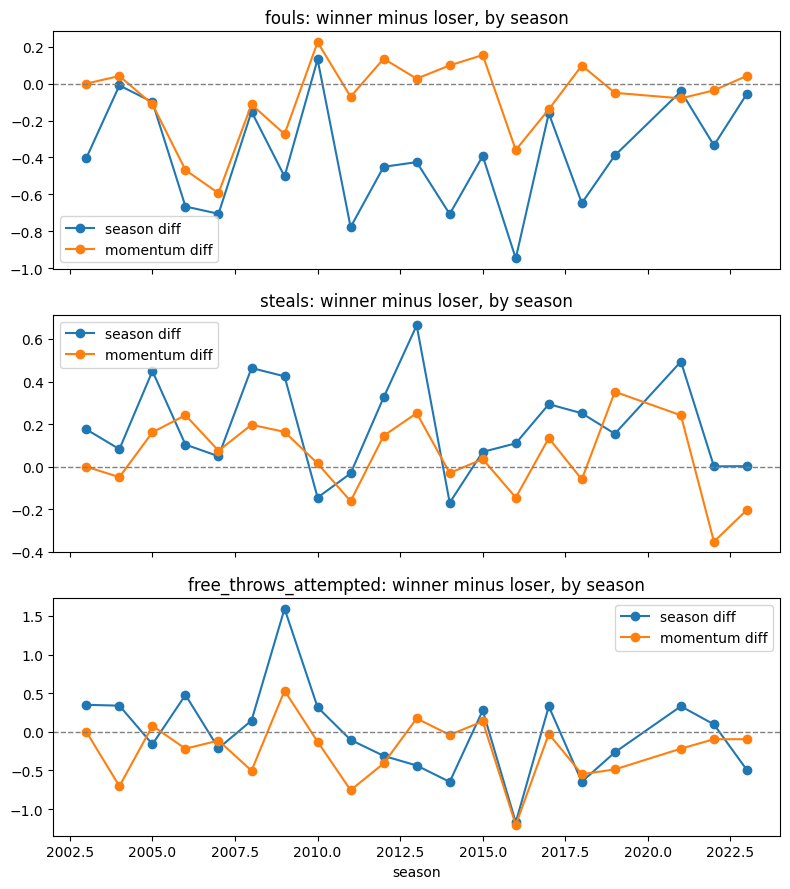

In [5]:
key_stats = ['fouls', 'steals', 'free_throws_attempted']

season_trend = all_matchups.groupby('Season')[[f'{s}_diff' for s in key_stats]].mean()
season_trend_momentum = all_matchups.groupby('Season')[[f'{s}_momentum_diff' for s in key_stats]].mean()

fig, axes = plt.subplots(len(key_stats), 1, figsize=(8, 3 * len(key_stats)), sharex=True)
for ax, stat in zip(axes, key_stats):
    ax.plot(season_trend.index, season_trend[f'{stat}_diff'], marker='o', label='season diff')
    ax.plot(season_trend_momentum.index, season_trend_momentum[f'{stat}_momentum_diff'], marker='o', label='momentum diff')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'{stat}: winner minus loser, by season')
    ax.legend()

axes[-1].set_xlabel('season')
plt.tight_layout()
plt.show()

In [9]:
config = load_config()
team_stats = pd.read_csv(f'{config["data"]["processed_dir"]}/team_stats_baseline.csv')
tourney_results = pd.read_csv('data/raw/MNCAATourneyCompactResults.csv')

train_start, train_end = config['data']['train_seasons']

stat_cols = ['points_scored', 'points_allowed', 'shots_made', 'shots_attempted', 'threes_made',
             'threes_attempted', 'free_throws_made', 'free_throws_attempted', 'offensive_rebounds',
             'defensive_rebounds', 'assists', 'turnovers', 'steals', 'blocks', 'fouls',
             'win_pct', 'fg_pct', 'three_pct', 'free_throw_pct']

# era-normalize each stat against that season's league-wide mean/std, so the model
# sees "how good relative to that year's league" rather than a raw time coordinate
for stat in stat_cols:
    season_mean = team_stats.groupby('season')[stat].transform('mean')
    season_std = team_stats.groupby('season')[stat].transform('std')
    season_std = season_std.replace(0, 1.0)
    team_stats[f'{stat}_era'] = (team_stats[stat] - season_mean) / season_std

train_stats = team_stats[(team_stats['season'] >= train_start) & (team_stats['season'] <= train_end)]
train_tourney = tourney_results[(tourney_results['Season'] >= train_start) & (tourney_results['Season'] <= train_end)]

winner_matchups = pd.merge(
    left=train_tourney, right=train_stats,
    left_on=['Season', 'WTeamID'], right_on=['season', 'team_id']
)
all_matchups = pd.merge(
    left=winner_matchups, right=train_stats,
    left_on=['Season', 'LTeamID'], right_on=['season', 'team_id'],
    suffixes=(None, '_l')
)

era_cols = [f'{stat}_era' for stat in stat_cols]
for stat in stat_cols + era_cols:
    all_matchups[f'{stat}_diff'] = all_matchups[stat] - all_matchups[f'{stat}_l']

diff_cols = [f'{stat}_diff' for stat in stat_cols]
era_diff_cols = [f'{stat}_diff' for stat in era_cols]

matchups = all_matchups[diff_cols + era_diff_cols].copy()
matchups['label'] = 1

mirrored = matchups.copy()
mirrored[diff_cols + era_diff_cols] = -mirrored[diff_cols + era_diff_cols]
mirrored['label'] = 0
matchups = pd.concat([matchups, mirrored], ignore_index=True)

screen_train, screen_val = train_test_split(
    matchups, test_size=0.2, random_state=config['training']['random_seed'], stratify=matchups['label']
)

results = []
for stat in stat_cols:
    base_col = f'{stat}_diff'
    era_col = f'{stat}_era_diff'

    corr, _ = pointbiserialr(matchups['label'], matchups[era_col])

    lr = LogisticRegression()
    lr.fit(screen_train[[era_col]], screen_train['label'])
    era_probs = lr.predict_proba(screen_val[[era_col]])[:, 1]
    era_auc = roc_auc_score(screen_val['label'], era_probs)

    redundancy = matchups[base_col].corr(matchups[era_col])

    results.append({
        'stat': stat,
        'era_corr': corr,
        'era_auc': era_auc,
        'redundancy_with_base': redundancy
    })

era_screen_df = pd.DataFrame(results).sort_values('era_auc', ascending=False)
era_screen_df

/var/folders/x8/pjxggchn73v63mqy7c5tz60r0000gn/T/ipykernel_54118/1237104156.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  all_matchups[f'{stat}_diff'] = all_matchups[stat] - all_matchups[f'{stat}_l']


,stat,era_corr,era_auc,redundancy_with_base
15,win_pct,0.327861,0.648708,0.999802
14,fouls,-0.155264,0.619136,0.999305
2,shots_made,0.253603,0.617936,0.997724
13,blocks,0.199123,0.605842,0.997092
0,points_scored,0.222950,0.598968,0.997865
1,points_allowed,-0.153583,0.592505,0.999203
8,offensive_rebounds,0.152599,0.589787,0.998979
3,shots_attempted,0.166962,0.588219,0.993082
16,fg_pct,0.198894,0.579942,0.998975
10,assists,0.200082,0.578872,0.999427


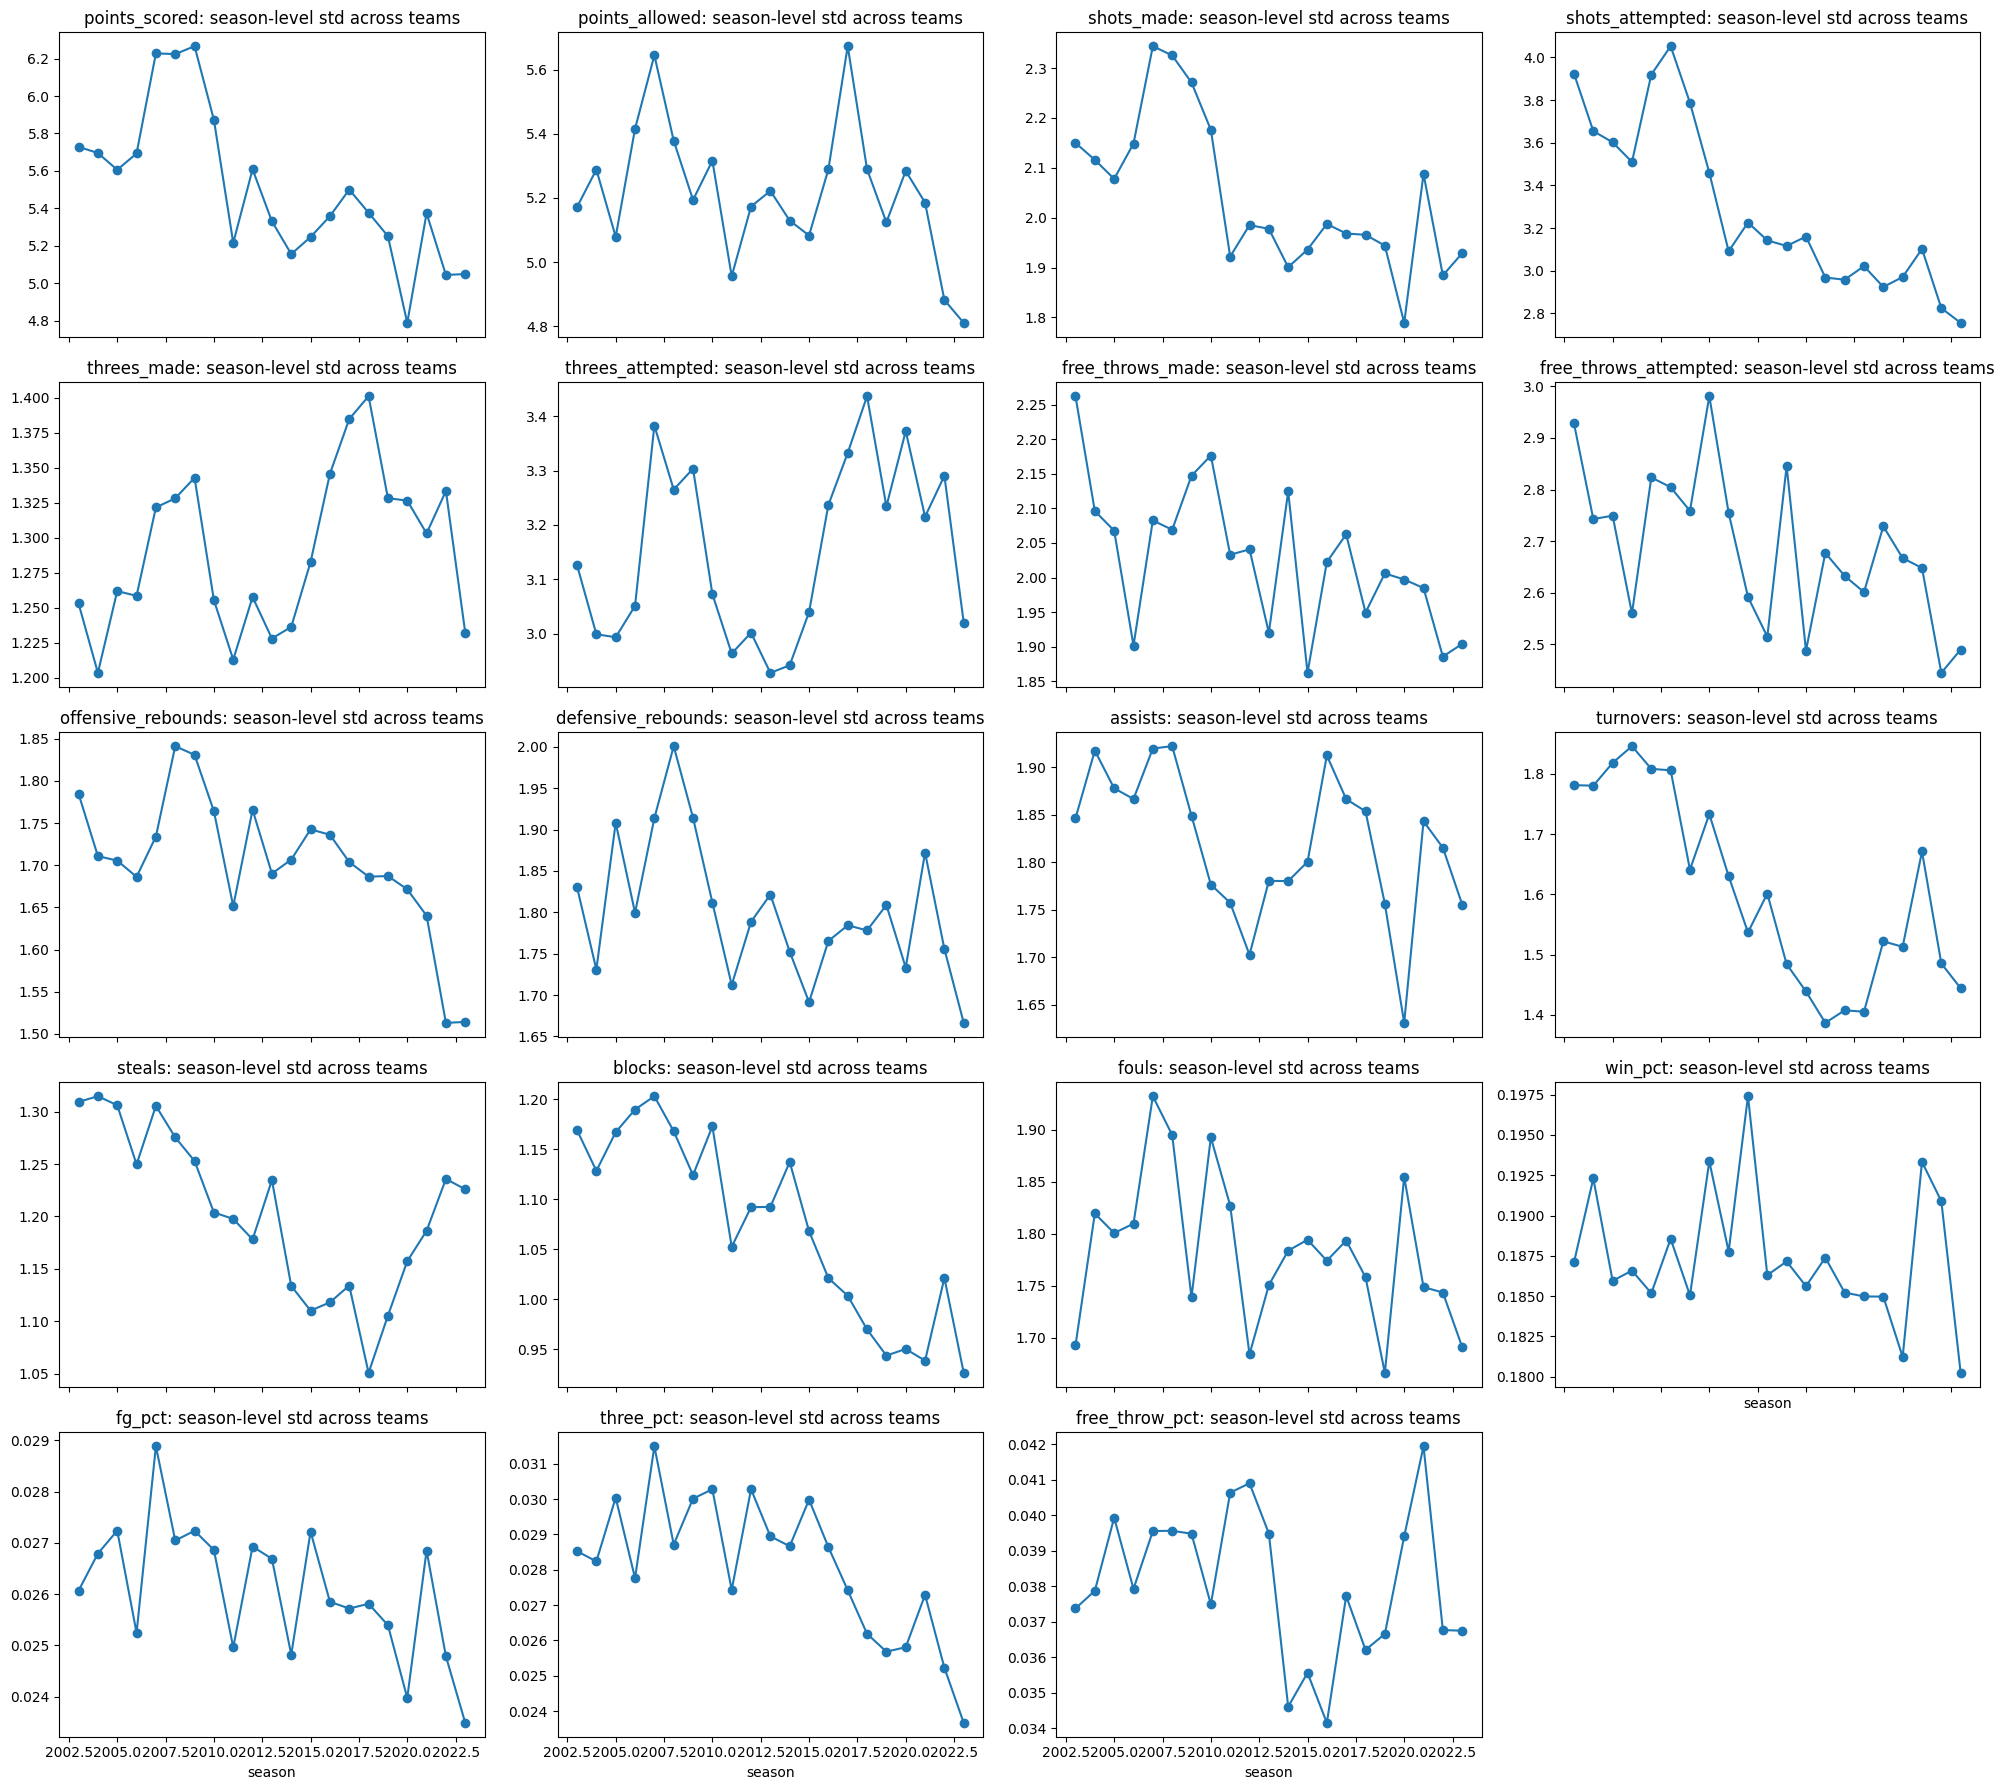

In [ ]:
season_std_trend = train_stats.groupby('season')[stat_cols].std()

fig, axes = plt.subplots(5, 4, figsize=(20, 18), sharex=True)
axes = axes.flatten()

for i, stat in enumerate(stat_cols):
    axes[i].plot(season_std_trend.index, season_std_trend[stat], marker='o')
    axes[i].set_title(f'{stat}: season-level std across teams')
    if i >= 15:
        axes[i].set_xlabel('season')
        
for j in range(len(stat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
std_summary = season_std_trend.agg(['mean', 'std']).T
std_summary['coefficient_of_variation'] = std_summary['std'] / std_summary['mean']
std_summary.sort_values('coefficient_of_variation', ascending=False)

,mean,std,coefficient_of_variation
shots_attempted,3.293791,0.394008,0.119621
turnovers,1.606717,0.157873,0.098258
blocks,1.073357,0.092391,0.086076
shots_made,2.042128,0.150388,0.073643
points_scored,5.506015,0.402676,0.073134
three_pct,0.028109,0.001979,0.070408
steals,1.204014,0.076995,0.063949
free_throw_pct,0.038101,0.002084,0.054696
free_throws_attempted,2.687289,0.145676,0.054209
threes_attempted,3.152660,0.163682,0.051919
